<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/DB_ScanClustaring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is a powerful unsupervised machine learning algorithm. Unlike K-Means or Hierarchical Clustering, which rely on distance to cluster centers, DBSCAN identifies clusters based on the **density of data points** in a given region.

This allows the algorithm to discover clusters of arbitrary shapes and automatically filter out noise (outliers).


## Core Hyperparameters

DBSCAN requires only two critical hyperparameters:

* **Epsilon ($\epsilon$):** The maximum radius of the neighborhood around a data point to look for other points.
* **MinSamples:** The minimum number of data points required within the $\epsilon$-neighborhood to form a dense region (including the point itself).


## Classification of Data Points

Once $\epsilon$ and $\text{MinSamples}$ are set, DBSCAN evaluates each data point and classifies it into one of three categories:

### 1. Core Points
A point is a **Core Point** if its $\epsilon$-neighborhood contains at least the minimum number of points specified by $\text{MinSamples}$.
$$\text{Count}(x_i, \epsilon) \ge \text{MinSamples}$$

### 2. Border Points
A point is a **Border Point** if it has fewer neighboring points than $\text{MinSamples}$ inside its radius, but it is close enough to falls within the $\epsilon$-neighborhood of an existing Core Point.

### 3. Noise Points (Outliers)
A point is a **Noise Point** if it is neither a Core Point nor a Border Point. These points are completely isolated from high-density regions and are assigned a cluster label of `-1`.

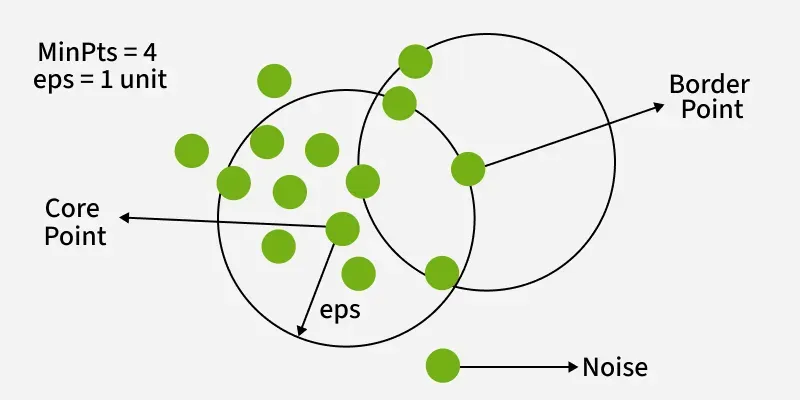

## How the Algorithm Works Step-by-Step

* **Step 1:** Select an unvisited data point at random.
* **Step 2:** Retrieve its $\epsilon$-neighborhood. If it qualifies as a **Core Point**, a new cluster is initiated. If not, the point is provisionally labeled as **Noise**.
* **Step 3:** If it is a Core Point, all points in its neighborhood are added to the cluster. If those neighbors are *also* Core Points, their respective neighborhoods are deeply expanded and folded into the same cluster.
* **Step 4:** This density-connected growth continues until no more core points can be reached within the neighborhood loop.
* **Step 5:** The algorithm picks a new unvisited point and repeats the process until every point in the dataset has been visited.


## Mathematical Formulation of Reachability

DBSCAN establishes relationships between points using two formal concepts:

* **Directly Density-Reachable:** A point $p$ is directly density-reachable from a point $q$ if $p$ is within the $\epsilon$-distance of $q$ and $q$ is a core point:
  $$\|p - q\| \le \epsilon$$

* **Density-Connected:** A point $p$ and a point $q$ are density-connected if there is a chain of intermediate core points $p_1, p_2, \dots, p_n$ such that each link in the chain is directly density-reachable from the previous one.

## Pros and Cons of DBSCAN

### Advantages
* **Arbitrary Shapes:** Can easily find complex, non-linear shapes (like concentric circles, crescent moons, or wavy paths) where K-Means completely fails.
* **No Predefined $K$:** You do not have to guess or hardcode the number of clusters ahead of time.
* **Outlier Handling:** Highly robust to anomalies; it flags noise out of the dataset automatically instead of forcing outliers into artificial clusters.

### Disadvantages
* **Varying Densities:** Fails if the dataset contains clusters with vastly different densities. A single $\epsilon$ radius cannot accommodate both sparse and highly compressed groups.
* **High-Dimensional Data:** Struggles in high dimensions because distance metrics become less meaningful (the Curse of Dimensionality).
* **Hyperparameter Sensitivity:** Finding the right combination of $\epsilon$ and $\text{MinSamples}$ can be difficult on complex, real-world datasets.


# ***Implement DBSCANNER ALgorithm***

In [2]:
#import all basic libaries
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from sklearn.datasets import make_moons
x,y=make_moons(n_samples=1000,noise=0.05)

In [4]:
x

array([[ 0.41210323, -0.25952118],
       [ 0.09467206,  0.12810268],
       [ 0.46277336,  0.93071441],
       ...,
       [-0.42584379,  0.94682907],
       [ 0.83639739,  0.62691632],
       [ 0.59409701, -0.41491514]])

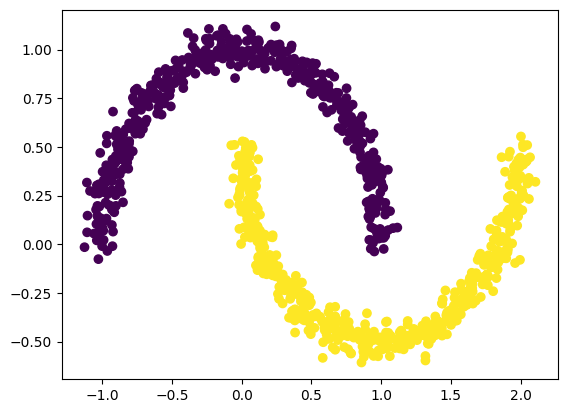

In [6]:
plt.scatter(x[:,0],x[:,1],c=y)

In [7]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [8]:
x_scaled

array([[-0.09980768, -1.02643929],
       [-0.46611326, -0.24467488],
       [-0.04133595,  1.374042  ],
       ...,
       [-1.06677216,  1.40654223],
       [ 0.38981442,  0.76133839],
       [ 0.11020742, -1.33983968]])

In [9]:
dbscan=DBSCAN(eps=0.2,min_samples=5)
dbscan.fit(x_scaled)

DBSCAN(eps=0.2)

In [10]:
dbscan.labels_

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,

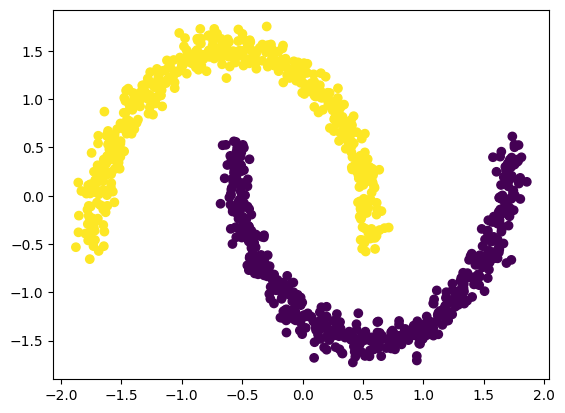

In [11]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=dbscan.labels_)